# CareerNova AI — Job Zone Prediction (fixed)

Changes from `CNN.ipynb`:

1. **Target leakage removed** — `Job_Zone` was both a feature and the label. It is removed from the features, along with `has_job_zone` (always 1 once unlabeled rows are dropped).
2. **No preprocessing leakage** — median imputation and scaling are fitted on the training split only (inside a `Pipeline`).
3. **Constant features dropped** — columns with a single value in the training set carry no information.
4. **Random Forest added** (the model named in the presentation), compared against a majority-class baseline, Logistic Regression and the 1D-CNN using stratified 5-fold cross-validation.
5. **Reproducible** — fixed random seeds and a relative dataset path.
6. **Macro F1 reported** alongside accuracy, because the classes are imbalanced.
7. **Skill counts recomputed** — the `*_count` columns in the CSV are only 0/1, so they are recounted from the `|`-separated skill lists.

In [1]:
import os
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Load data

Put the CSV in the same folder as this notebook.

In [2]:
DATA_PATH = "Career_Nova_Final_Clean_Optimized_Dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

Dataset shape: (1016, 19)


## Fix the skill count columns

In the CSV, the `*_count` columns are only ever 0 or 1 (they flag whether a list is non-empty). The real lists are stored as `" | "`-separated text, so the counts are recomputed from them here.

In [3]:
def count_items(text):
    if pd.isna(text) or not str(text).strip():
        return 0
    return len([item for item in str(text).split("|") if item.strip()])


count_columns = {
    "essential_skill_count": "essential_skills",
    "software_skill_count": "software_skills",
    "hot_technology_count": "hot_technologies",
    "in_demand_software_count": "in_demand_software",
}

for count_column, list_column in count_columns.items():
    before = df[count_column].max()
    df[count_column] = df[list_column].apply(count_items)
    print(f"{count_column:26s} max before: {before}   after: {df[count_column].max()}")

essential_skill_count      max before: 1   after: 10
software_skill_count       max before: 2   after: 430
hot_technology_count       max before: 1   after: 152
in_demand_software_count   max before: 1   after: 38


## Features and target

`Job_Zone` is the target, so it must **not** be a feature.

In [4]:
TARGET = "Job_Zone"

features = [
    "essential_skill_count",
    "avg_essential_importance",
    "max_essential_importance",
    "software_skill_count",
    "hot_technology_count",
    "in_demand_software_count",
    "has_essential_skills",
    "has_software_skills",
    "data_completeness_pct"
]

assert TARGET not in features, "Target must not be used as a feature"

for column in features + [TARGET]:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Drop rows without a label BEFORE any imputation
df = df[df[TARGET].notna()].reset_index(drop=True)

X = df[features]
y = df[TARGET]

print("X shape:", X.shape)
print(y.value_counts().sort_index())

X shape: (923, 9)
Job_Zone
2.0    337
3.0    208
4.0    226
5.0    152
Name: count, dtype: int64


In [5]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

print("Classes:", label_encoder.classes_)

Classes: [2. 3. 4. 5.]


## Train / test split

The test set is held out until the very end. Model selection uses 5-fold CV on the training set only.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=SEED,
    stratify=y_encoded
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 738
Testing samples: 185


In [7]:
# Drop features that are constant in the training set (no information)
constant = [c for c in features if X_train[c].nunique(dropna=True) <= 1]
features = [c for c in features if c not in constant]

X_train = X_train[features]
X_test = X_test[features]

print("Dropped constant features:", constant)
print("Final features:", features)

Dropped constant features: ['has_software_skills']
Final features: ['essential_skill_count', 'avg_essential_importance', 'max_essential_importance', 'software_skill_count', 'hot_technology_count', 'in_demand_software_count', 'has_essential_skills', 'data_completeness_pct']


In [8]:
# Sanity check: no single feature should almost perfectly predict the target
print(
    X_train.assign(target=y_train)
    .corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(key=abs, ascending=False)
)

avg_essential_importance    0.843984
max_essential_importance    0.762333
software_skill_count        0.325560
in_demand_software_count    0.291910
hot_technology_count        0.283356
has_essential_skills        0.019983
essential_skill_count       0.019983
data_completeness_pct       0.019983
Name: target, dtype: float64


## Classical models — stratified 5-fold CV

Imputation and scaling sit inside each pipeline, so they are re-fitted on every training fold.

In [9]:
def make_pipeline(model, scale=False):
    steps = [("impute", SimpleImputer(strategy="median"))]
    if scale:
        steps.append(("scale", StandardScaler()))
    steps.append(("model", model))
    return Pipeline(steps)


models = {
    "Baseline (majority class)": make_pipeline(
        DummyClassifier(strategy="most_frequent")
    ),
    "Logistic Regression": make_pipeline(
        LogisticRegression(max_iter=2000, random_state=SEED),
        scale=True
    ),
    "Random Forest": make_pipeline(
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1
        )
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = {}

for name, pipeline in models.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "f1_macro"]
    )
    cv_results[name] = {
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Accuracy (std)": scores["test_accuracy"].std(),
        "CV Macro F1": scores["test_f1_macro"].mean(),
        "CV Macro F1 (std)": scores["test_f1_macro"].std(),
    }
    print(f"{name:28s} acc={cv_results[name]['CV Accuracy']:.4f}  macroF1={cv_results[name]['CV Macro F1']:.4f}")

Baseline (majority class)    acc=0.3645  macroF1=0.1336
Logistic Regression          acc=0.6911  macroF1=0.6621
Random Forest                acc=0.6884  macroF1=0.6694


## 1D-CNN — same 5-fold CV

Kept for comparison. Note that Conv1D assumes neighbouring columns are related, which is not true for tabular features, so it is not expected to beat tree models here.

In [10]:
def build_cnn(n_features):
    model = Sequential([
        Input(shape=(n_features, 1)),
        # padding="same" keeps this valid even if only a few features remain
        Conv1D(filters=32, kernel_size=3, padding="same", activation="relu"),
        MaxPooling1D(pool_size=2, padding="same"),
        Conv1D(filters=64, kernel_size=3, padding="same", activation="relu"),
        Flatten(),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def prepare_cnn_inputs(X_fit, X_other):
    # Imputer and scaler are fitted on X_fit only
    prep = make_pipeline("passthrough", scale=True)
    X_fit = prep.fit_transform(X_fit)
    X_other = prep.transform(X_other)
    return X_fit[..., np.newaxis], X_other[..., np.newaxis]


def fit_cnn(X_fit, y_fit):
    model = build_cnn(X_fit.shape[1])
    history = model.fit(
        X_fit,
        to_categorical(y_fit, num_classes),
        epochs=100,
        batch_size=32,
        validation_split=0.20,
        callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
        verbose=0
    )
    return model, history


fold_acc, fold_f1 = [], []

for train_idx, val_idx in cv.split(X_train, y_train):
    X_fold_train, X_fold_val = prepare_cnn_inputs(
        X_train.iloc[train_idx], X_train.iloc[val_idx]
    )
    model, _ = fit_cnn(X_fold_train, y_train[train_idx])
    pred = np.argmax(model.predict(X_fold_val, verbose=0), axis=1)
    fold_acc.append(accuracy_score(y_train[val_idx], pred))
    fold_f1.append(f1_score(y_train[val_idx], pred, average="macro"))

cv_results["1D-CNN"] = {
    "CV Accuracy": np.mean(fold_acc),
    "CV Accuracy (std)": np.std(fold_acc),
    "CV Macro F1": np.mean(fold_f1),
    "CV Macro F1 (std)": np.std(fold_f1),
}

print(f"1D-CNN  acc={np.mean(fold_acc):.4f}  macroF1={np.mean(fold_f1):.4f}")

1D-CNN  acc=0.7006  macroF1=0.6754


## Final evaluation on the held-out test set

In [11]:
test_results = {}
test_predictions = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    test_predictions[name] = pipeline.predict(X_test)

X_train_cnn, X_test_cnn = prepare_cnn_inputs(X_train, X_test)
cnn_model, cnn_history = fit_cnn(X_train_cnn, y_train)
test_predictions["1D-CNN"] = np.argmax(cnn_model.predict(X_test_cnn, verbose=0), axis=1)

for name, pred in test_predictions.items():
    test_results[name] = {
        "Test Accuracy": accuracy_score(y_test, pred),
        "Test Macro F1": f1_score(y_test, pred, average="macro"),
        "Test Weighted F1": f1_score(y_test, pred, average="weighted"),
    }

results = pd.concat(
    [pd.DataFrame(cv_results).T, pd.DataFrame(test_results).T],
    axis=1
).sort_values("CV Macro F1", ascending=False)

print("=" * 60)
print("CAREER NOVA — MODEL COMPARISON")
print("=" * 60)
print(results.round(4).to_string())

CAREER NOVA — MODEL COMPARISON
                           CV Accuracy  CV Accuracy (std)  CV Macro F1  CV Macro F1 (std)  Test Accuracy  Test Macro F1  Test Weighted F1
1D-CNN                          0.7006             0.0418       0.6754             0.0423         0.6595         0.6259            0.6522
Random Forest                   0.6884             0.0327       0.6694             0.0348         0.6486         0.6119            0.6407
Logistic Regression             0.6911             0.0362       0.6621             0.0319         0.6541         0.6216            0.6460
Baseline (majority class)       0.3645             0.0034       0.1336             0.0009         0.3676         0.1344            0.1976


Best model (by CV macro F1): 1D-CNN

              precision    recall  f1-score   support

      Zone 2       0.77      0.82      0.79        68
      Zone 3       0.47      0.38      0.42        42
      Zone 4       0.67      0.71      0.69        45
      Zone 5       0.60      0.60      0.60        30

    accuracy                           0.66       185
   macro avg       0.63      0.63      0.63       185
weighted avg       0.65      0.66      0.65       185



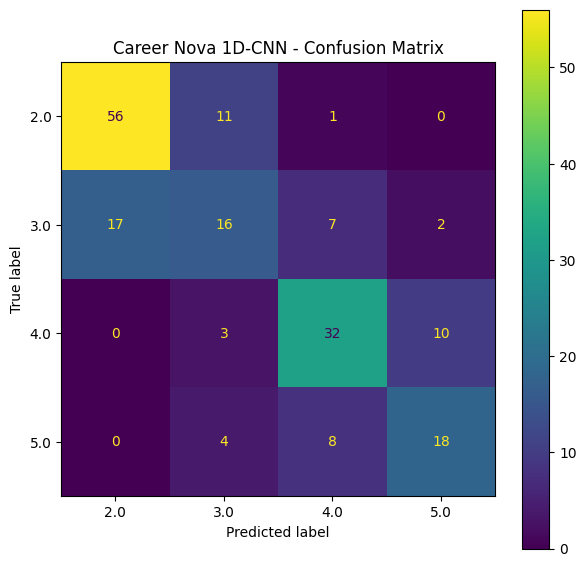

In [12]:
best_name = results.drop("Baseline (majority class)").index[0]
best_pred = test_predictions[best_name]

print("Best model (by CV macro F1):", best_name)
print()
print(classification_report(
    y_test,
    best_pred,
    target_names=[f"Zone {int(c)}" for c in label_encoder.classes_]
))

fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, best_pred),
    display_labels=label_encoder.classes_
).plot(ax=ax, values_format="d")
plt.title(f"Career Nova {best_name} - Confusion Matrix")
plt.show()

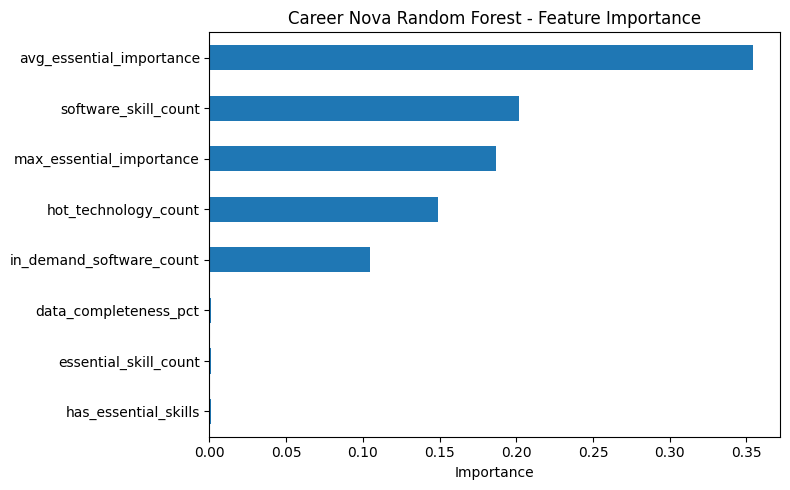

In [13]:
rf = models["Random Forest"].named_steps["model"]

importances = pd.Series(rf.feature_importances_, index=features).sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind="barh")
plt.xlabel("Importance")
plt.title("Career Nova Random Forest - Feature Importance")
plt.tight_layout()
plt.show()

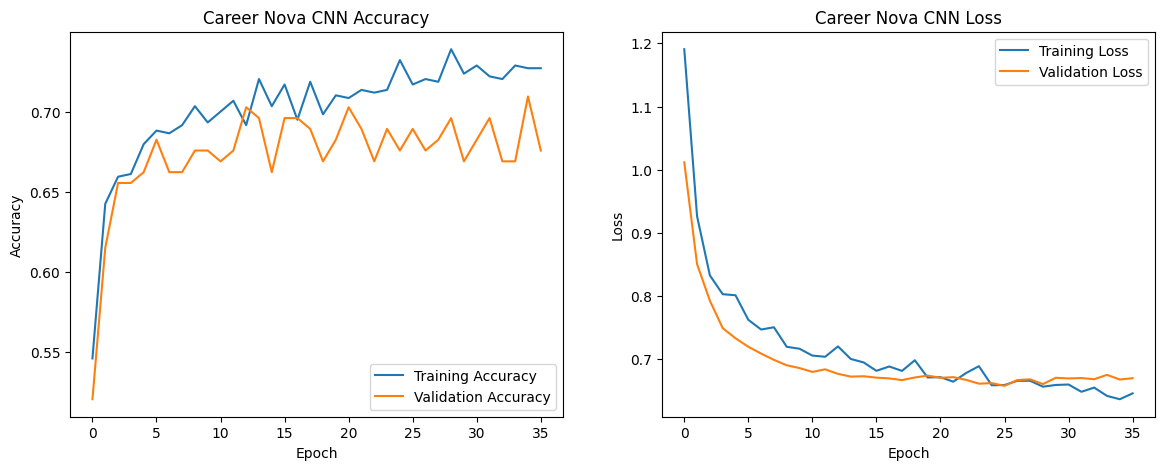

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cnn_history.history["accuracy"], label="Training Accuracy")
axes[0].plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Career Nova CNN Accuracy")
axes[0].legend()

axes[1].plot(cnn_history.history["loss"], label="Training Loss")
axes[1].plot(cnn_history.history["val_loss"], label="Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Career Nova CNN Loss")
axes[1].legend()

plt.show()